# 03 — Baseline model comparison

- Three **untuned** baselines: Logistic Regression, Random Forest, HistGradientBoosting.
- Each model runs inside the shared preprocessing Pipeline, re-fitted per fold (`src/churn/modeling.py`).
- Repeated stratified 5-fold CV (× 3 repeats) on the **training set only**; every model sees identical folds. The test set is not used.
- Threshold-free metrics (ROC-AUC, PR-AUC, Brier, log loss) compare probability quality. Precision / recall / F1 use the default 0.5 threshold, which is **not** a business-chosen threshold; threshold selection comes later.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

from churn.config import FIGURES_DIR, PROCESSED_DATA_DIR, REPORTS_DIR
from churn.data import load_dataset, split_features_target, split_train_test
from churn.evaluation import confusion_at_threshold
from churn.modeling import BASELINE_MODELS, cross_validate_models, summarize_cv

%matplotlib inline
pd.set_option("display.precision", 4)

MODEL_STYLE = {  # colour-blind-safe slots + line style as secondary encoding
    "LogisticRegression": ("#2a78d6", "-"),
    "RandomForest": ("#eb6834", "--"),
    "HistGradientBoosting": ("#1baf7a", ":"),
}
TEXT, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10, "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Data and split

In [2]:
train_df, test_df = split_train_test(load_dataset())
X_train, y_train = split_features_target(train_df)
del test_df  # held out until final evaluation

print(f"Training rows: {len(X_train)}, churn rate {y_train.mean():.2%}")

Training rows: 5634, churn rate 26.54%


## 2. Cross-validation

In [3]:
start = time.perf_counter()
cv_result = cross_validate_models(X_train, y_train)
print(f"CV finished in {time.perf_counter() - start:.0f}s: "
      f"{len(BASELINE_MODELS)} models × {cv_result.fold_metrics['fold'].nunique()} folds")

# Record results: per-fold metrics (committed) and out-of-fold probabilities (reproducible, git-ignored).
cv_result.fold_metrics.to_csv(REPORTS_DIR / "cv_baseline_fold_metrics.csv", index=False)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
cv_result.oof_predictions.to_csv(PROCESSED_DATA_DIR / "oof_baseline_predictions.csv", index=False)

CV finished in 25s: 3 models × 15 folds


In [4]:
summary = summarize_cv(cv_result.fold_metrics)
metric_order = ["roc_auc", "pr_auc", "precision", "recall", "f1", "brier", "log_loss", "train_roc_auc"]
summary = summary[metric_order].loc[list(BASELINE_MODELS)]
summary.to_csv(REPORTS_DIR / "cv_baseline_summary.csv")

readable = pd.DataFrame({
    metric: summary[(metric, "mean")].map("{:.4f}".format) + " ± " + summary[(metric, "std")].map("{:.4f}".format)
    for metric in metric_order
})
readable

,roc_auc,pr_auc,precision,recall,f1,brier,log_loss,train_roc_auc
model,,,,,,,,
LogisticRegression,0.8463 ± 0.0121,0.6612 ± 0.0176,0.6543 ± 0.0253,0.5454 ± 0.0359,0.5942 ± 0.0249,0.1350 ± 0.0044,0.4169 ± 0.0136,0.8496 ± 0.0030
RandomForest,0.8263 ± 0.0134,0.6205 ± 0.0286,0.6367 ± 0.0275,0.4979 ± 0.0382,0.5582 ± 0.0299,0.1438 ± 0.0058,0.4667 ± 0.0319,1.0000 ± 0.0000
HistGradientBoosting,0.8366 ± 0.0107,0.6499 ± 0.0204,0.6429 ± 0.0241,0.5226 ± 0.0334,0.5758 ± 0.0215,0.1399 ± 0.0045,0.4352 ± 0.0165,0.9624 ± 0.0019


Higher is better except **Brier** and **log loss** (probability error; lower is better). `train_roc_auc` is measured on the training folds, to compare against validation ROC-AUC for overfitting.

### 2.1 Paired differences vs. Logistic Regression

Same folds for every model, so per-fold differences remove shared fold difficulty. Positive = better than Logistic Regression (for Brier / log loss, negative = better).

In [5]:
fm = cv_result.fold_metrics.set_index(["model", "fold"])
baseline = fm.loc["LogisticRegression"]
rows = []
for name in ["RandomForest", "HistGradientBoosting"]:
    diff = fm.loc[name] - baseline
    for metric in ["roc_auc", "pr_auc", "f1", "brier", "log_loss"]:
        d = diff[metric]
        better = (d < 0) if metric in ("brier", "log_loss") else (d > 0)
        rows.append({"model": name, "metric": metric, "mean_diff": d.mean(),
                     "std_error": d.std(ddof=1) / np.sqrt(len(d)),
                     "folds_better": f"{int(better.sum())}/{len(d)}"})
pd.DataFrame(rows).set_index(["model", "metric"])

mean_diff  std_error folds_better
model                metric                                     
RandomForest         roc_auc     -0.0200     0.0029         0/15
                     pr_auc      -0.0407     0.0051         0/15
                     f1          -0.0360     0.0080         2/15
                     brier        0.0088     0.0011         0/15
                     log_loss     0.0498     0.0061         0/15
HistGradientBoosting roc_auc     -0.0097     0.0015         1/15
                     pr_auc      -0.0112     0.0028         2/15
                     f1          -0.0184     0.0061         2/15
                     brier        0.0049     0.0006         0/15
                     log_loss     0.0183     0.0018         0/15

### 2.2 Overfitting check (train vs. validation ROC-AUC)

In [6]:
gap = cv_result.fold_metrics.groupby("model")[["train_roc_auc", "roc_auc"]].mean().loc[list(BASELINE_MODELS)]
gap["gap"] = gap["train_roc_auc"] - gap["roc_auc"]
gap

,train_roc_auc,roc_auc,gap
model,,,
LogisticRegression,0.8496,0.8463,0.0033
RandomForest,1.0000,0.8263,0.1736
HistGradientBoosting,0.9624,0.8366,0.1258


## 3. Probability-based evaluation (out-of-fold, first CV repeat)

Every training row gets exactly one out-of-fold prediction per repeat, so these curves are built from predictions on data each model did not train on.

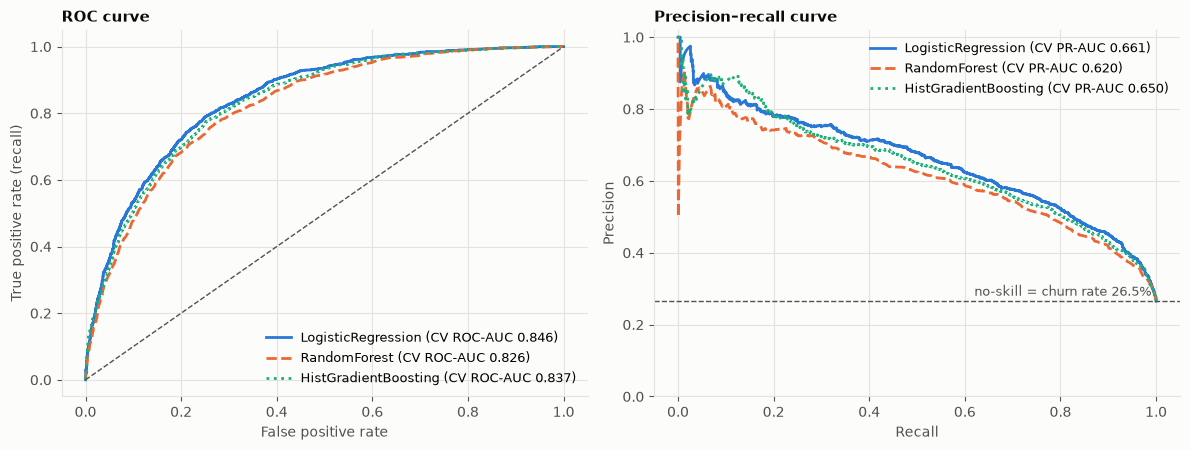

In [7]:
oof = cv_result.oof_predictions.query("repeat == 0")
base_rate = y_train.mean()

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.6))
for name, (color, style) in MODEL_STYLE.items():
    part = oof[oof["model"] == name]
    fpr, tpr, _ = roc_curve(part["y_true"], part["proba"])
    prec, rec, _ = precision_recall_curve(part["y_true"], part["proba"])
    auc = summary.loc[name, ("roc_auc", "mean")]
    ap = summary.loc[name, ("pr_auc", "mean")]
    ax_roc.plot(fpr, tpr, color=color, ls=style, lw=2, label=f"{name} (CV ROC-AUC {auc:.3f})")
    ax_pr.plot(rec, prec, color=color, ls=style, lw=2, label=f"{name} (CV PR-AUC {ap:.3f})")

ax_roc.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax_roc.set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curve")
ax_pr.axhline(base_rate, color=MUTED, lw=1, ls="--")
ax_pr.text(0.99, base_rate + 0.015, f"no-skill = churn rate {base_rate:.1%}", ha="right", color=MUTED, fontsize=9)
ax_pr.set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve", ylim=(0, 1.02))
for ax in (ax_roc, ax_pr):
    ax.legend(loc="lower right" if ax is ax_roc else "upper right", fontsize=9)
fig.tight_layout()
save(fig, "14_baseline_roc_pr_curves")
plt.show()

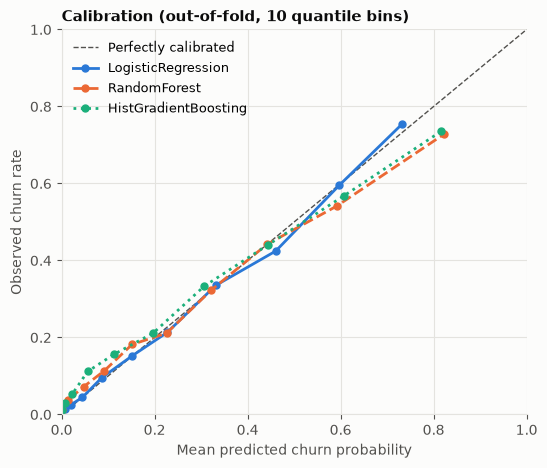

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Perfectly calibrated")
for name, (color, style) in MODEL_STYLE.items():
    part = oof[oof["model"] == name]
    frac_pos, mean_pred = calibration_curve(part["y_true"], part["proba"], n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, color=color, ls=style, lw=2, marker="o", markersize=5, label=name)
ax.set(xlabel="Mean predicted churn probability", ylabel="Observed churn rate",
       title="Calibration (out-of-fold, 10 quantile bins)", xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=9)
save(fig, "15_baseline_calibration")
plt.show()

## 4. Confusion matrices at threshold 0.5 (out-of-fold, first CV repeat)

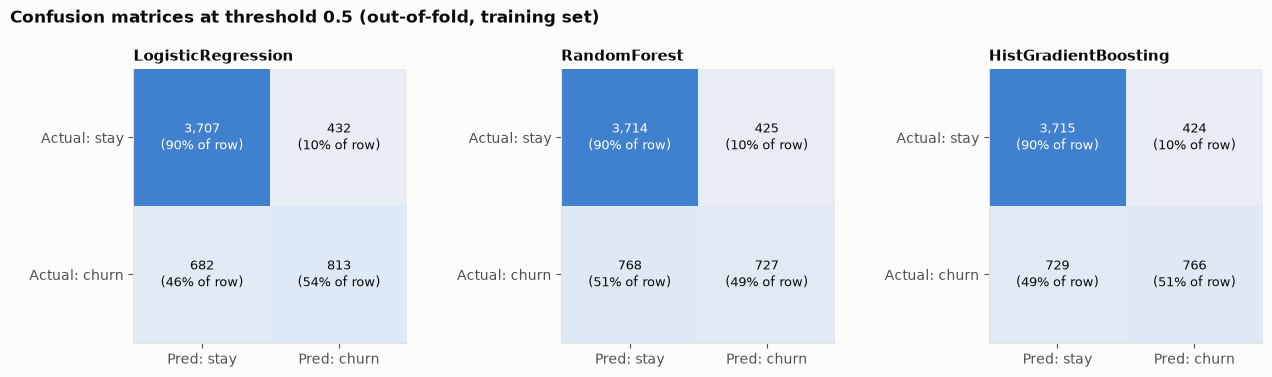

,TN,FP,FN,TP,predicted_churn_rate
model,,,,,
LogisticRegression,3707,432,682,813,0.2210
RandomForest,3714,425,768,727,0.2045
HistGradientBoosting,3715,424,729,766,0.2112


In [9]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("blue_ramp", ["#f4f3f0", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
cm_rows = []
for ax, name in zip(axes, MODEL_STYLE):
    part = oof[oof["model"] == name]
    cm = confusion_at_threshold(part["y_true"], part["proba"])
    (tn, fp), (fn, tp) = cm
    cm_rows.append({"model": name, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                    "predicted_churn_rate": (fp + tp) / cm.sum()})
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.sum())
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, f"{value:,}\n({value / cm[i].sum():.0%} of row)", ha="center", va="center",
                fontsize=9.5, color="white" if value > cm.sum() * 0.45 else TEXT)
    ax.set_xticks([0, 1], ["Pred: stay", "Pred: churn"])
    ax.set_yticks([0, 1], ["Actual: stay", "Actual: churn"])
    ax.grid(False)
    ax.set_title(name)
fig.suptitle("Confusion matrices at threshold 0.5 (out-of-fold, training set)", x=0.01, ha="left",
             fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "16_baseline_confusion_matrices")
plt.show()
pd.DataFrame(cm_rows).set_index("model")

## 5. Findings (baseline, untuned — not a final model choice)

**Ranking quality:** Logistic Regression is ahead on every threshold-free metric, and consistently so across folds:
- vs. HistGradientBoosting: ROC-AUC −0.010 (HGB better in 1/15 folds), PR-AUC −0.011 (2/15).
- vs. RandomForest: ROC-AUC −0.020, PR-AUC −0.041 (RF better in 0/15 folds on both).

**Overfitting:** the tree ensembles use library defaults and fit the training folds far better than they generalize (train ROC-AUC 1.000 for RandomForest, 0.962 for HistGradientBoosting, vs. ~0.83–0.84 validation). Logistic Regression's gap is 0.003. The tree models are likely under-regularized; their gap to Logistic Regression could shrink with tuning.

**Probability quality:** all three are reasonably calibrated; Logistic Regression has the lowest Brier score and log loss. The tree models slightly over-predict churn at the high-probability end.

**At threshold 0.5:** every model predicts churn for ~20–22% of customers and misses about half of actual churners (recall 0.50–0.55). This is a property of the default threshold, not of the models: a retention use case would likely choose a lower threshold to raise recall at some cost in precision. Threshold choice is deferred to evaluation.

**Caveats:** differences are small in absolute terms (≈0.01–0.02 ROC-AUC); all results are from training-set CV; the test set remains unused.